In [69]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from utils import load_runs, rf_importance

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

ENTITY  = "andrea02polimi-politecnico-di-milano"
PROJECT = "christiano_final_experiments"
CACHE   = Path("../data_for_training/sweep_cache.csv")

HP_COLS = [
    "lr_rew", "gradient_steps_rew", "batch_size_rew",
    "fragment_length", "fragmenter_type", "labels_type",
    "net_arch", "total_queries",
]

TARGET_METRICS = {
    "success_rate":         "successes",
    "ep_avg_speed":         "ep_avg_speed",
    "accuracy_val":         "acc_val",
    "ep_fast_return":       "ep_fast_return",
    "ep_length":            "ep_length",
    "time/train_rew_model": "time_train_rew_model",
}

In [70]:
df_all = load_runs(ENTITY, PROJECT, CACHE, force_reload=False)
df = df_all[df_all["state"] == "finished"].copy().reset_index(drop=True)
df["fragment_length"] = df["fragment_length"].fillna("None")
print(f"Run finite: {len(df)} / {len(df_all)}")

Caricato da cache: ../data_for_training/sweep_cache.csv
Run finite: 199 / 207


In [71]:
NUMERIC_METRICS = ["successes", "timeouts", "collisions", "ep_length",
                   "ep_avg_speed", "ep_fast_return", "acc_val", "acc_gap",
                   "spearman_seg1", "time_train_rew_model"]
DISPLAY_COLS    = HP_COLS + NUMERIC_METRICS

sortable = [c for c in NUMERIC_METRICS if df[c].notna().any()]

sort_w       = widgets.Dropdown(options=sortable, value="successes",
                                description="Ordina per:", style={"description_width": "initial"})
asc_w        = widgets.Checkbox(value=False, description="Ascendente")
filter_col_w = widgets.Dropdown(options=["(nessuno)"] + sortable, value="acc_val",
                                description="Filtra su:", style={"description_width": "initial"})
filter_min_w = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.01,
                                   description="Min:", readout_format=".2f")
n_rows_w     = widgets.IntSlider(value=20, min=5, max=50, step=5, description="N righe:")

out = widgets.Output()

def _update(*_):
    sub = df.copy()
    fc  = filter_col_w.value
    if fc != "(nessuno)":
        sub = sub[sub[fc] >= filter_min_w.value]
    sub = sub.sort_values(sort_w.value, ascending=asc_w.value).head(n_rows_w.value)
    sub["wandb"] = sub["run_id"].apply(
        lambda rid: f"https://wandb.ai/{ENTITY}/{PROJECT}/runs/{rid}"
    )
    cols     = [c for c in DISPLAY_COLS if c in sub.columns] + ["wandb"]
    num_cols = [c for c in NUMERIC_METRICS if c in sub.columns]
    styled = (
        sub[cols].style
        .background_gradient(subset=["successes"], cmap="Greens")
        .background_gradient(subset=["timeouts"],  cmap="Reds_r")
        .background_gradient(subset=[c for c in ["acc_val", "spearman_seg1"] if c in sub.columns], cmap="Blues")
        .format({c: "{:.3f}" for c in num_cols})
        .format({"wandb": lambda x: f'<a href="{x}" target="_blank">link</a>'})
        .hide(axis="index")
    )
    with out:
        out.clear_output(wait=True)
        display(styled)

for w in [sort_w, asc_w, filter_col_w, filter_min_w, n_rows_w]:
    w.observe(_update, names="value")

display(widgets.VBox([
    widgets.HBox([sort_w, asc_w]),
    widgets.HBox([filter_col_w, filter_min_w, n_rows_w]),
    out,
]))
_update()

/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/notebooks/utils.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["fragment_length"].replace("None", -1)
/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/notebooks/utils.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["fragment_length"].replace("None", -1)
/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/notebooks/utils.py:86: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old beh

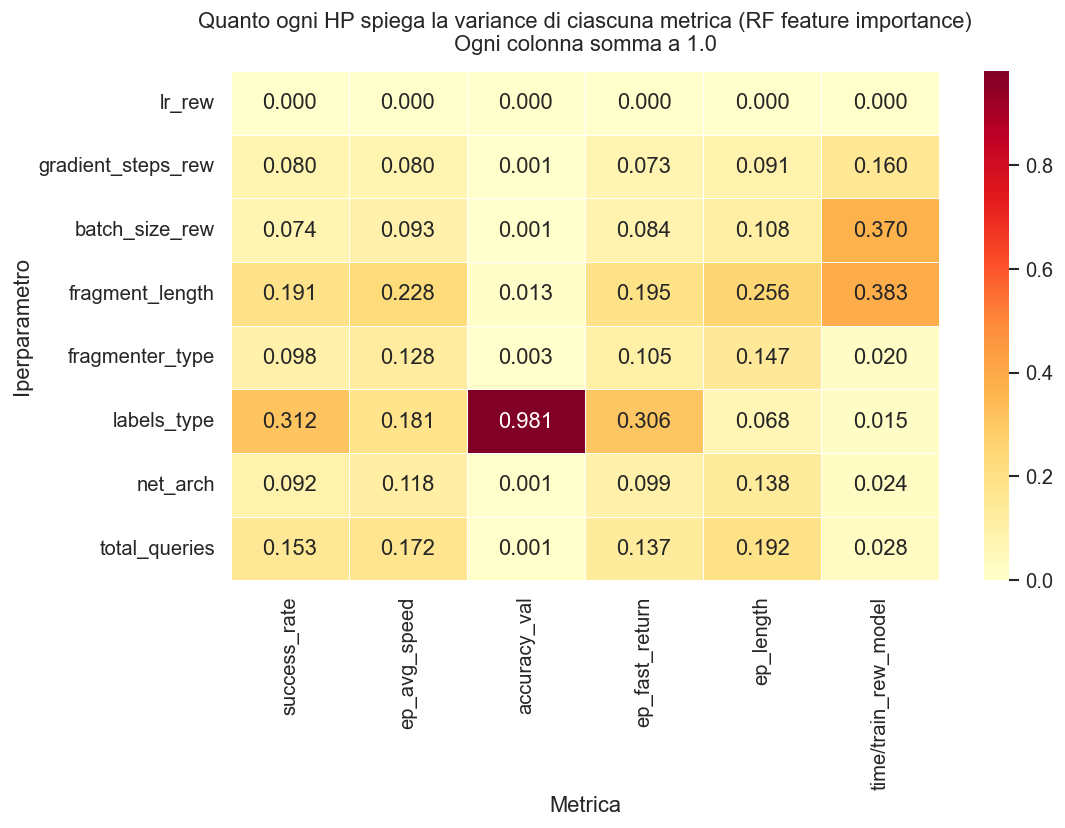

In [72]:
imp_df = rf_importance(df, HP_COLS, TARGET_METRICS)

fig, ax = plt.subplots(figsize=(max(6, len(imp_df.columns) * 1.6), len(HP_COLS) * 0.7 + 1.5))
sns.heatmap(imp_df, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, vmin=0, vmax=imp_df.values.max(), ax=ax)
ax.set_title("Quanto ogni HP spiega la variance di ciascuna metrica (RF feature importance)\n"
             "Ogni colonna somma a 1.0", pad=12)
ax.set_xlabel("Metrica")
ax.set_ylabel("Iperparametro")
plt.tight_layout()
plt.show()

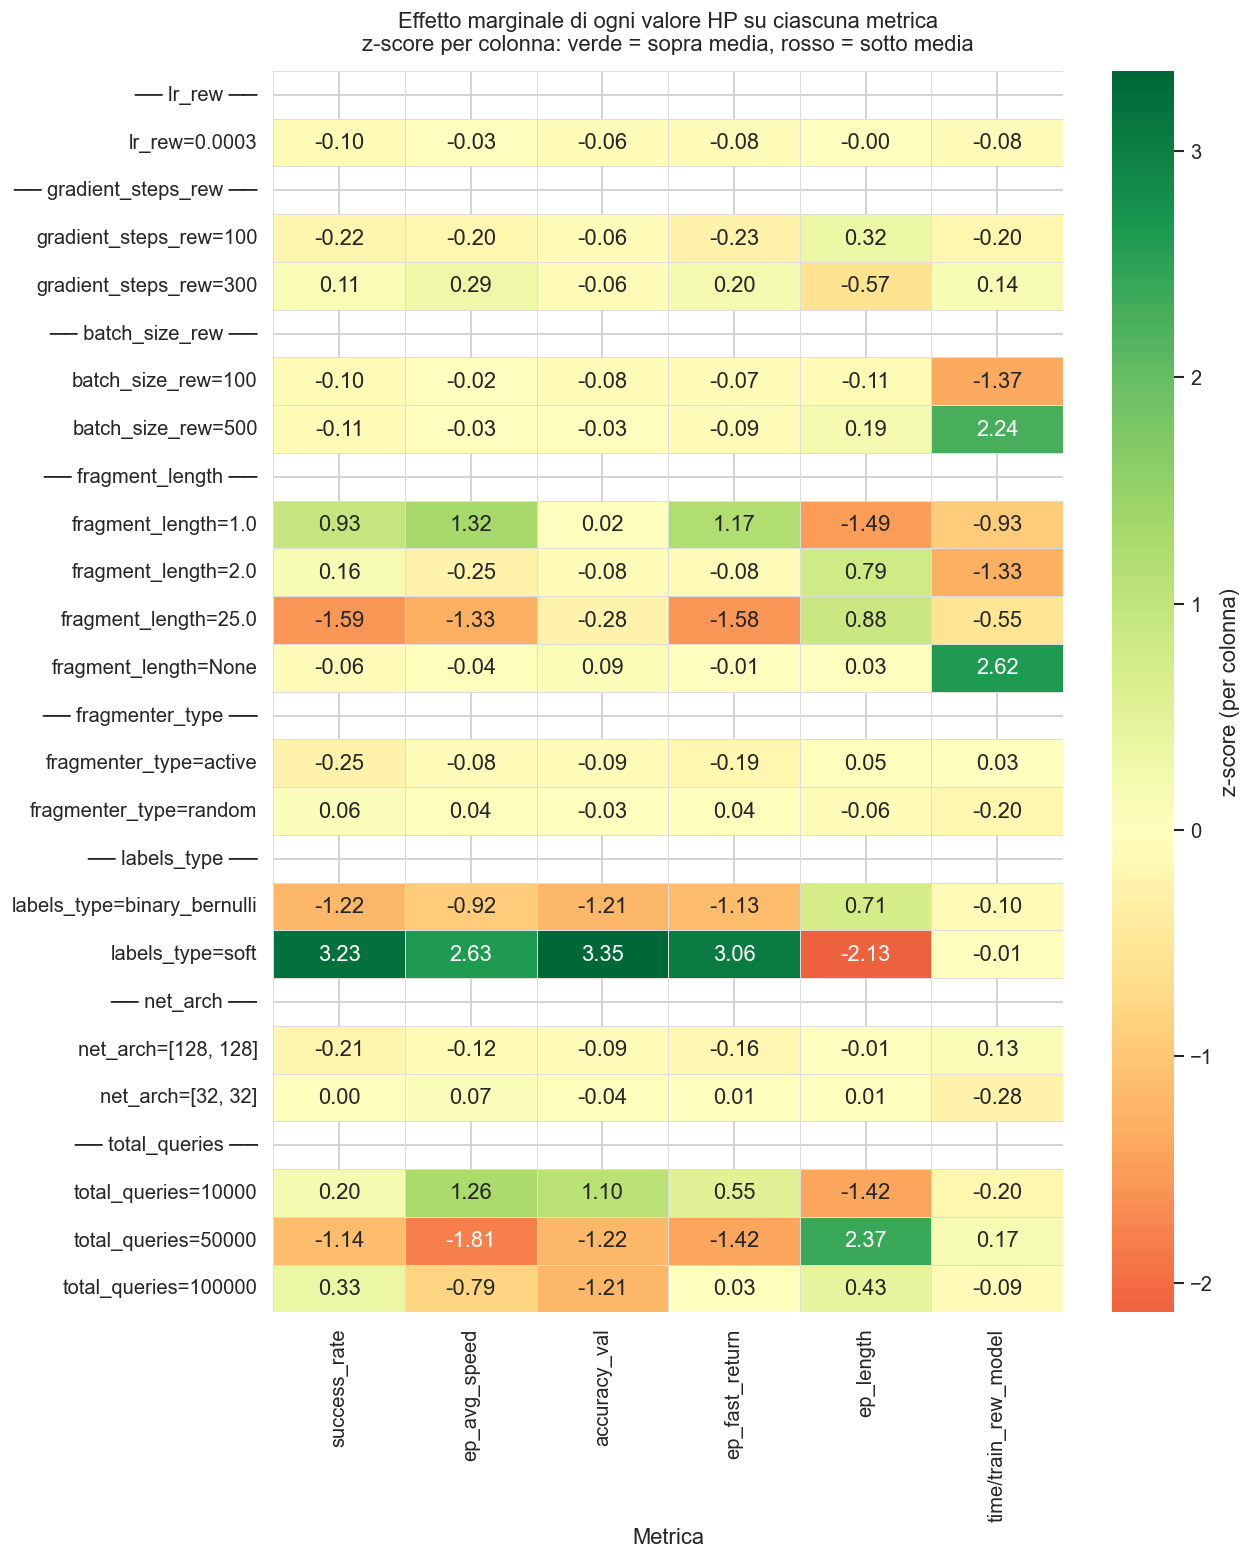

In [73]:
available_metrics = {label: col for label, col in TARGET_METRICS.items() if col in df.columns}
metric_cols       = list(available_metrics.keys())

records = []
for hp in HP_COLS:
    for val in sorted(df[hp].unique(), key=lambda x: (str(type(x)), x)):
        mask = df[hp] == val
        row  = {"label": f"{hp}={val}"}
        for label, col in available_metrics.items():
            row[label] = df.loc[mask, col].mean()
        records.append(row)

marginal_df = pd.DataFrame(records).set_index("label")

norm_df = marginal_df[metric_cols].copy()
for col in metric_cols:
    std = norm_df[col].std()
    norm_df[col] = (norm_df[col] - norm_df[col].mean()) / std if std > 0 else 0.0

blocks = []
for hp in HP_COLS:
    spacer = pd.DataFrame([[np.nan] * len(metric_cols)],
                          columns=metric_cols, index=[f"── {hp} ──"])
    block  = norm_df[[r.startswith(f"{hp}=") for r in norm_df.index]]
    blocks.extend([spacer, block])
plot_df = pd.concat(blocks)

fig, ax = plt.subplots(figsize=(max(7, len(metric_cols) * 1.8), len(plot_df) * 0.45 + 1.5))
sns.heatmap(plot_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.4, linecolor="#dddddd", ax=ax,
            cbar_kws={"label": "z-score (per colonna)"})
ax.set_title("Effetto marginale di ogni valore HP su ciascuna metrica\n"
             "z-score per colonna: verde = sopra media, rosso = sotto media", pad=12)
ax.set_xlabel("Metrica")
ax.set_ylabel("")
plt.tight_layout()
plt.show()